# March Madness 2026 Head-to-Head Matchup Predictor
## Any Two Tournament Teams, Win Probability + Projected Scores

**Model:** LightGBM/LogReg Ensemble (65/35 weight)
**Score Projection:** Tempo-efficiency framework + Monte Carlo simulation (50,000 iterations)
**Output:** Win probability, projected final score with 90% confidence interval, stat comparison dashboard

In [1]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
warnings.filterwarnings('ignore')

DATA_DIR = "C:/Users/gordo/Documents/madness_2026/mm_data"
CURRENT_YEAR = 2026
AVG_TEMPO = 67.5
AVG_EFF = 107.0
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

FEATURE_COLS = [
    "seed_diff", "oe_diff", "de_diff", "eff_margin_diff",
    "barthag_diff", "rank_diff", "win_pct_diff", "tempo_diff",
    "oe_rank_diff", "de_rank_diff",
]

print("Setup complete.")

Setup complete.


## 1. Load 2026 Tournament Teams + Trained Model

In [2]:
import requests

def load_barttorvik_2026():
    path = os.path.join(DATA_DIR, f"barttorvik_{CURRENT_YEAR}.json")
    if not os.path.exists(path):
        url = f"https://barttorvik.com/{CURRENT_YEAR}_team_results.json"
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code == 200:
            os.makedirs(DATA_DIR, exist_ok=True)
            with open(path, "w") as f:
                f.write(r.text)
    with open(path) as f:
        data = json.load(f)
    teams = {}
    for t in data:
        rec = t[3] if len(t) > 3 else "0-0"
        w, l = 0, 0
        if isinstance(rec, str) and '-' in rec:
            parts = rec.split('-')
            w, l = int(parts[0]), int(parts[1])
        total = w + l if (w + l) > 0 else 1
        teams[t[1]] = {
            "rank": t[0], "conf": t[2], "record": rec,
            "wins": w, "losses": l, "win_pct": w / total,
            "adj_oe": t[4] if len(t) > 4 else 100.0,
            "adj_oe_rank": t[5] if len(t) > 5 else 180,
            "adj_de": t[6] if len(t) > 6 else 100.0,
            "adj_de_rank": t[7] if len(t) > 7 else 180,
            "barthag": t[8] if len(t) > 8 else 0.5,
            "barthag_rank": t[9] if len(t) > 9 else 180,
            "adj_tempo": t[44] if len(t) > 44 else 67.0,
            "eff_margin": (t[4] - t[6]) if len(t) > 6 else 0.0,
        }
    return teams

bt_data = load_barttorvik_2026()
print(f"Loaded {len(bt_data)} teams from Barttorvik 2026")

TOURN_TEAMS = {
    "East": {"Duke":1,"Siena":16,"Ohio St.":8,"TCU":9,"St. John's":5,"Northern Iowa":12,"Kansas":4,"Cal Baptist":13,"Louisville":6,"South Florida":11,"Michigan St.":3,"North Dakota St.":14,"UCLA":7,"UCF":10,"Connecticut":2,"Furman":15},
    "South": {"Florida":1,"Lehigh":16,"Clemson":8,"Iowa":9,"Vanderbilt":5,"McNeese St.":12,"Nebraska":4,"Troy":13,"North Carolina":6,"VCU":11,"Illinois":3,"Penn":14,"Saint Mary's":7,"Texas A&M":10,"Houston":2,"Idaho":15},
    "West": {"Arizona":1,"Long Island":16,"Villanova":8,"Utah St.":9,"Wisconsin":5,"High Point":12,"Arkansas":4,"Hawaii":13,"BYU":6,"Texas":11,"Gonzaga":3,"Kennesaw St.":14,"Miami FL":7,"Missouri":10,"Purdue":2,"Queens":15},
    "Midwest": {"Michigan":1,"Howard":16,"Georgia":8,"Saint Louis":9,"Texas Tech":5,"Akron":12,"Alabama":4,"Hofstra":13,"Tennessee":6,"SMU":11,"Virginia":3,"Wright St.":14,"Kentucky":7,"Santa Clara":10,"Iowa St.":2,"Tennessee St.":15},
    "First Four": {"UMBC":16,"N.C. State":11,"Prairie View A&M":16,"Miami OH":11},
}

all_teams = {}
for region, tdict in TOURN_TEAMS.items():
    for team, seed in tdict.items():
        all_teams[team] = {"seed": seed, "region": region}

team_list = sorted(all_teams.keys())
found = sum(1 for t in team_list if t in bt_data)
print(f"\n{found}/{len(team_list)} tournament teams matched in Barttorvik data")

model_path = os.path.join(DATA_DIR, "trained_model.pkl")
if os.path.exists(model_path):
    with open(model_path, "rb") as f:
        m = pickle.load(f)
    lr_model, lgb_model, scaler = m["lr"], m["lgb"], m["scaler"]
    print("Trained model loaded successfully")
else:
    print("ERROR: No trained model found. Run march_madness_bracket_predictor.py first.")

Loaded 365 teams from Barttorvik 2026

67/68 tournament teams matched in Barttorvik data
Trained model loaded successfully


## 2. Available Tournament Teams

In [3]:
print(f"{'#':>3s}  {'Seed':>4s}  {'Team':<25s}  {'Region':<10s}  {'T-Rank':>6s}  {'Record':>8s}  {'AdjOE':>6s}  {'AdjDE':>6s}  {'Margin':>7s}")
print("-" * 95)
for i, team in enumerate(team_list):
    info = all_teams[team]
    s = bt_data.get(team, {})
    if s:
        print(f"{i+1:>3d}  ({info['seed']:>2d})  {team:<25s}  {info['region']:<10s}  #{s.get('rank',0):>4d}  {str(s.get('record','?')):>8s}  {s.get('adj_oe',0):6.1f}  {s.get('adj_de',0):6.1f}  {s.get('eff_margin',0):+7.1f}")
    else:
        print(f"{i+1:>3d}  ({info['seed']:>2d})  {team:<25s}  {info['region']:<10s}  -- no stats --")

  #  Seed  Team                       Region      T-Rank    Record   AdjOE   AdjDE   Margin
-----------------------------------------------------------------------------------------------
  1  (12)  Akron                      Midwest     #  71      29-5   117.2   105.4    +11.8
  2  ( 4)  Alabama                    Midwest     #  18      23-9   129.5   102.8    +26.7
  3  ( 1)  Arizona                    West        #   3      32-2   126.9    91.4    +35.5
  4  ( 4)  Arkansas                   West        #  19      26-8   127.9   101.6    +26.3
  5  ( 6)  BYU                        West        #  33     23-11   124.7   104.3    +20.4
  6  (13)  Cal Baptist                East        #  96      25-8   107.5   100.3     +7.2
  7  ( 8)  Clemson                    South       #  30     24-10   116.6    97.0    +19.6
  8  ( 2)  Connecticut                East        #   9      29-5   123.1    95.0    +28.1
  9  ( 1)  Duke                       East        #   1      32-2   128.2    90.8   

## 3. Run a Head-to-Head Matchup

**Change `TEAM_A` and `TEAM_B` below to any two tournament teams.**
Use the exact team name from the list above.

In [4]:
TEAM_A = "Duke"
TEAM_B = "Michigan"

a_seed = all_teams[TEAM_A]["seed"]
b_seed = all_teams[TEAM_B]["seed"]
a_stats = bt_data[TEAM_A]
b_stats = bt_data[TEAM_B]

features = np.array([[
    a_seed - b_seed, a_stats["adj_oe"] - b_stats["adj_oe"],
    a_stats["adj_de"] - b_stats["adj_de"],
    a_stats["eff_margin"] - b_stats["eff_margin"],
    a_stats["barthag"] - b_stats["barthag"],
    a_stats["rank"] - b_stats["rank"],
    a_stats["win_pct"] - b_stats["win_pct"],
    a_stats["adj_tempo"] - b_stats["adj_tempo"],
    a_stats["adj_oe_rank"] - b_stats["adj_oe_rank"],
    a_stats["adj_de_rank"] - b_stats["adj_de_rank"],
]])
X = scaler.transform(features)
lr_prob = lr_model.predict_proba(X)[0][1]
lgb_prob = lgb_model.predict_proba(X)[0][1] if lgb_model else lr_prob
ml_prob = 0.65 * lr_prob + 0.35 * lgb_prob

tempo_a, tempo_b = a_stats["adj_tempo"], b_stats["adj_tempo"]
expected_poss = (tempo_a * tempo_b) / AVG_TEMPO
ppp_a = (a_stats["adj_oe"] * b_stats["adj_de"]) / (AVG_EFF * 100)
ppp_b = (b_stats["adj_oe"] * a_stats["adj_de"]) / (AVG_EFF * 100)
proj_a = ppp_a * expected_poss
proj_b = ppp_b * expected_poss

N_SIMS = 50000
scores_a = np.maximum(np.random.normal(proj_a, 11.0, N_SIMS), 30)
scores_b = np.maximum(np.random.normal(proj_b, 11.0, N_SIMS), 30)
mc_a_wins = np.sum(scores_a > scores_b) + np.sum(scores_a == scores_b) // 2
mc_prob = mc_a_wins / N_SIMS
combined_prob = 0.6 * ml_prob + 0.4 * mc_prob

print(f"\n{'='*65}")
print(f"  ({a_seed}) {TEAM_A}  vs  ({b_seed}) {TEAM_B}")
print(f"{'='*65}")
print(f"\n  ML Model Win Prob:     {TEAM_A} {ml_prob*100:.1f}% / {TEAM_B} {(1-ml_prob)*100:.1f}%")
print(f"  Monte Carlo Win Prob:  {TEAM_A} {mc_prob*100:.1f}% / {TEAM_B} {(1-mc_prob)*100:.1f}%")
print(f"  Combined:              {TEAM_A} {combined_prob*100:.1f}% / {TEAM_B} {(1-combined_prob)*100:.1f}%")
print(f"\n  Projected Score: {TEAM_A} {proj_a:.0f}, {TEAM_B} {proj_b:.0f}")
print(f"  Expected Possessions: {expected_poss:.1f}")
print(f"  Margin: {TEAM_A} by {np.mean(scores_a - scores_b):+.1f} pts")
print(f"  P(close game <3 pts): {np.mean(np.abs(scores_a - scores_b) < 3)*100:.1f}%")
print(f"  P(blowout >10 pts):   {np.mean(np.abs(scores_a - scores_b) > 10)*100:.1f}%")


  (1) Duke  vs  (1) Michigan

  ML Model Win Prob:     Duke 54.8% / Michigan 45.2%
  Monte Carlo Win Prob:  Duke 51.5% / Michigan 48.5%
  Combined:              Duke 53.5% / Michigan 46.5%

  Projected Score: Duke 76, Michigan 75
  Expected Possessions: 69.4
  Margin: Duke by +0.5 pts
  P(close game <3 pts): 15.3%
  P(blowout >10 pts):   51.9%


## 4. Score Distribution Visualization

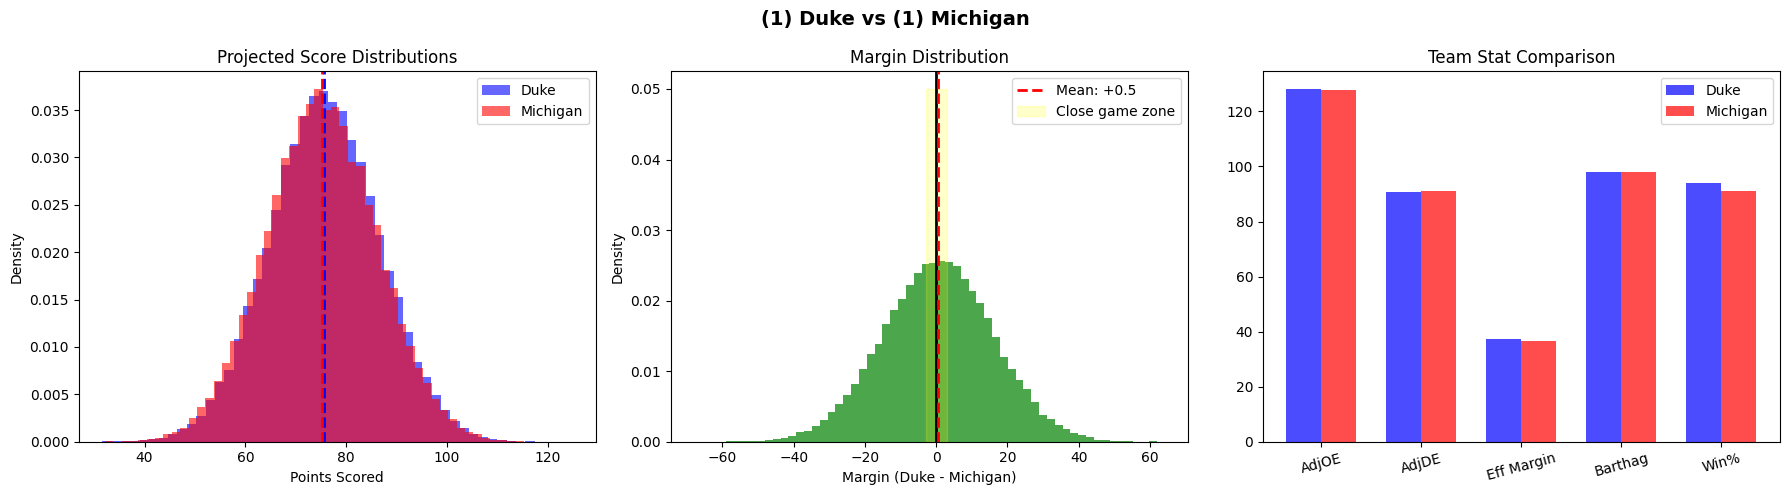

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax1 = axes[0]
ax1.hist(scores_a, bins=50, alpha=0.6, color='blue', label=TEAM_A, density=True)
ax1.hist(scores_b, bins=50, alpha=0.6, color='red', label=TEAM_B, density=True)
ax1.axvline(proj_a, color='blue', linestyle='--', linewidth=2)
ax1.axvline(proj_b, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel("Points Scored")
ax1.set_ylabel("Density")
ax1.set_title("Projected Score Distributions")
ax1.legend()

ax2 = axes[1]
margins = scores_a - scores_b
ax2.hist(margins, bins=60, color='green', alpha=0.7, density=True)
ax2.axvline(0, color='black', linewidth=2, linestyle='-')
ax2.axvline(np.mean(margins), color='red', linewidth=2, linestyle='--', label=f"Mean: {np.mean(margins):+.1f}")
ax2.fill_betweenx([0, 0.05], -3, 3, alpha=0.2, color='yellow', label="Close game zone")
ax2.set_xlabel(f"Margin ({TEAM_A} - {TEAM_B})")
ax2.set_ylabel("Density")
ax2.set_title("Margin Distribution")
ax2.legend()

ax3 = axes[2]
stats_labels = ["AdjOE", "AdjDE", "Eff Margin", "Barthag", "Win%"]
a_vals = [a_stats["adj_oe"], a_stats["adj_de"], a_stats["eff_margin"], a_stats["barthag"]*100, a_stats["win_pct"]*100]
b_vals = [b_stats["adj_oe"], b_stats["adj_de"], b_stats["eff_margin"], b_stats["barthag"]*100, b_stats["win_pct"]*100]
x = np.arange(len(stats_labels))
width = 0.35
bars1 = ax3.bar(x - width/2, a_vals, width, label=TEAM_A, color='blue', alpha=0.7)
bars2 = ax3.bar(x + width/2, b_vals, width, label=TEAM_B, color='red', alpha=0.7)
ax3.set_xticks(x)
ax3.set_xticklabels(stats_labels, rotation=15)
ax3.set_title("Team Stat Comparison")
ax3.legend()

plt.suptitle(f"({a_seed}) {TEAM_A} vs ({b_seed}) {TEAM_B}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Full Stat Comparison Table

In [6]:
comparison = pd.DataFrame({
    "Metric": ["Record", "T-Rank", "Adj. Off. Efficiency", "Adj. Def. Efficiency",
               "Efficiency Margin", "Barthag (Win%)", "Adj. Tempo", "Conference"],
    TEAM_A: [
        a_stats["record"], f"#{a_stats['rank']}", f"{a_stats['adj_oe']:.1f} (#{a_stats['adj_oe_rank']})",
        f"{a_stats['adj_de']:.1f} (#{a_stats['adj_de_rank']})", f"{a_stats['eff_margin']:+.1f}",
        f"{a_stats['barthag']:.4f}", f"{a_stats['adj_tempo']:.1f}", a_stats["conf"],
    ],
    TEAM_B: [
        b_stats["record"], f"#{b_stats['rank']}", f"{b_stats['adj_oe']:.1f} (#{b_stats['adj_oe_rank']})",
        f"{b_stats['adj_de']:.1f} (#{b_stats['adj_de_rank']})", f"{b_stats['eff_margin']:+.1f}",
        f"{b_stats['barthag']:.4f}", f"{b_stats['adj_tempo']:.1f}", b_stats["conf"],
    ],
})
comparison.set_index("Metric", inplace=True)
display(comparison)

,Duke,Michigan
Metric,,
Record,32-2,31-3
T-Rank,#1,#2
Adj. Off. Efficiency,128.2 (#4),127.7 (#6)
Adj. Def. Efficiency,90.8 (#1),91.0 (#2)
Efficiency Margin,+37.4,+36.6
Barthag (Win%),0.9813,0.9799
Adj. Tempo,65.8,71.2
Conference,ACC,B10


## 6. Run Multiple Matchups at Once

In [7]:
MATCHUPS = [
    ("Duke", "Arizona"),
    ("Michigan", "Houston"),
    ("Florida", "Connecticut"),
    ("Purdue", "Iowa St."),
    ("Duke", "Michigan"),
    ("Arizona", "Houston"),
]

print(f"{'Matchup':<35s}  {'Team A Win%':>12s}  {'Team B Win%':>12s}  {'Proj Score':>15s}")
print("-" * 80)
for name_a, name_b in MATCHUPS:
    sa = all_teams[name_a]["seed"]
    sb = all_teams[name_b]["seed"]
    sta = bt_data.get(name_a)
    stb = bt_data.get(name_b)
    if not sta or not stb:
        continue
    feats = np.array([[
        sa-sb, sta["adj_oe"]-stb["adj_oe"], sta["adj_de"]-stb["adj_de"],
        sta["eff_margin"]-stb["eff_margin"], sta["barthag"]-stb["barthag"],
        sta["rank"]-stb["rank"], sta["win_pct"]-stb["win_pct"],
        sta["adj_tempo"]-stb["adj_tempo"],
        sta["adj_oe_rank"]-stb["adj_oe_rank"], sta["adj_de_rank"]-stb["adj_de_rank"],
    ]])
    Xf = scaler.transform(feats)
    p = lr_model.predict_proba(Xf)[0][1]
    if lgb_model:
        p2 = lgb_model.predict_proba(Xf)[0][1]
        p = 0.65*p + 0.35*p2
    poss = (sta["adj_tempo"]*stb["adj_tempo"])/AVG_TEMPO
    pa = (sta["adj_oe"]*stb["adj_de"])/(AVG_EFF*100)*poss
    pb = (stb["adj_oe"]*sta["adj_de"])/(AVG_EFF*100)*poss
    label = f"({sa}) {name_a} vs ({sb}) {name_b}"
    print(f"{label:<35s}  {p*100:>11.1f}%  {(1-p)*100:>11.1f}%  {name_a} {pa:.0f}-{pb:.0f}")

Matchup                               Team A Win%   Team B Win%       Proj Score
--------------------------------------------------------------------------------
(1) Duke vs (1) Arizona                     57.6%         42.4%  Duke 75-74
(1) Michigan vs (2) Houston                 68.2%         31.8%  Michigan 74-71
(1) Florida vs (2) Connecticut              71.2%         28.8%  Florida 75-71
(2) Purdue vs (2) Iowa St.                  60.1%         39.9%  Purdue 74-74
(1) Duke vs (1) Michigan                    54.8%         45.2%  Duke 76-75
(1) Arizona vs (2) Houston                  62.8%         37.2%  Arizona 72-70
